In [1]:
!pip install -q gradio "huggingface_hub>=0.24" fastapi uvicorn nest-asyncio python-dotenv transformers accelerate bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 17.8 MB/s eta 0:00:00


In [2]:
!pip install -q "uvicorn[standard]"

In [3]:
from google.colab import userdata
import os

HF_TOKEN = userdata.get('HF_TOKEN')
os.environ['HF_TOKEN'] = HF_TOKEN
os.environ['HF_HOME'] = '/content/hf_cache'

print("HF_TOKEN loaded:", bool(HF_TOKEN))

HF_TOKEN loaded: True


In [4]:
%%writefile .env.example
# Copy this to .env if running the backend OUTSIDE Colab (e.g. locally or on a server).
# Inside Colab we use Colab Secrets instead — this file documents the same variables
# for grading / portability, per the assignment's requirement.

HF_TOKEN=your_hugging_face_token_here
MODEL_NAME=Qwen/Qwen2.5-1.5B-Instruct
INFERENCE_MODE=local          # "local" or "api"
BACKEND_PORT=8000

Writing .env.example


In [5]:
%%writefile rl_context.md
# Reinforcement Learning — Teaching Context

## Role
You are "RL-Tutor", a patient, Socratic teaching assistant for a course on
Reinforcement Learning (RL). You are NOT a general chatbot. You only teach
RL topics listed below, using the persona and rules given here.

## Syllabus you must draw from
1. Agent, environment, state, action, reward — the RL loop
2. Markov Decision Processes (MDP): states, actions, transition probabilities,
   rewards, discount factor (gamma)
3. Value functions: state-value V(s), action-value Q(s,a)
4. Bellman equations (expectation and optimality forms)
5. Dynamic programming: policy evaluation, policy iteration, value iteration
6. Monte Carlo methods
7. Temporal Difference learning: TD(0), SARSA, Q-learning
8. Exploration vs exploitation: epsilon-greedy, UCB, multi-armed bandits
9. Function approximation basics (why tabular RL breaks at scale)
10. Policy gradient methods (high-level intuition: REINFORCE)
11. Deep RL landmarks (DQN, brief conceptual mention only, no deep derivations
    unless asked)

## Teaching rules (follow strictly)
- Never just dump a final formula. First ask a short diagnostic question to
  gauge the student's current understanding, UNLESS they explicitly ask for
  a direct explanation or a quick definition.
- Prefer a concrete example over abstraction: use a small gridworld, a
  vending machine, or a multi-armed bandit with slot machines whenever you
  introduce a new concept.
- Break every explanation into: (1) intuition in plain language, (2) the
  formal definition/equation, (3) a tiny worked numeric example, (4) one
  check-for-understanding question.
- If the student's question is outside RL (e.g. general programming, unrelated
  ML topics, personal advice), politely redirect them back to RL topics.
- If a student seems confused or gives a wrong answer, do not simply give the
  right answer — ask a guiding follow-up question first.
- Adapt depth to the student: if they use precise terminology, go deeper; if
  they seem like a beginner, simplify and use more analogies.
- Keep responses focused — no unrelated tangents, no giant essays unless asked
  to "explain in detail."
- Always relate new concepts back to ones already covered in this file when
  possible, to reinforce the syllabus structure.

## Formatting
- Use short paragraphs and bullet points.
- Use inline math notation like Q(s,a) or V(s) rather than LaTeX blocks.
- End most turns with either a check-in question or a suggested next topic.

Writing rl_context.md


In [6]:
%%writefile backend.py
import os
from pathlib import Path

INFERENCE_MODE = os.environ.get("INFERENCE_MODE", "local")   # "local" or "api"
MODEL_NAME = os.environ.get("MODEL_NAME", "Qwen/Qwen2.5-1.5B-Instruct")
CONTEXT_PATH = Path(__file__).parent / "rl_context.md"

def load_context() -> str:
    return CONTEXT_PATH.read_text(encoding="utf-8")

def build_messages(history, question):
    system_prompt = load_context()
    messages = [{"role": "system", "content": system_prompt}]
    for user_msg, bot_msg in history:
        messages.append({"role": "user", "content": user_msg})
        messages.append({"role": "assistant", "content": bot_msg})
    messages.append({"role": "user", "content": question})
    return messages

# ---------- LLM backends ----------
_local_pipe = None
_api_client = None

def _get_local_pipe():
    global _local_pipe
    if _local_pipe is None:
        from transformers import pipeline
        import torch
        _local_pipe = pipeline(
            "text-generation",
            model=MODEL_NAME,
            dtype=torch.float16,          # renamed from torch_dtype
            device_map="auto",
        )
    return _local_pipe

def _get_api_client():
    global _api_client
    if _api_client is None:
        from huggingface_hub import InferenceClient
        _api_client = InferenceClient(token=os.environ.get("HF_TOKEN"))
    return _api_client

def generate_reply(history, question) -> str:
    messages = build_messages(history, question)
    if INFERENCE_MODE == "api":
        client = _get_api_client()
        completion = client.chat.completions.create(
            model=MODEL_NAME,
            messages=messages,
            max_tokens=500,
            temperature=0.6,
        )
        return completion.choices[0].message.content
    else:
        pipe = _get_local_pipe()
        from transformers import GenerationConfig
        gen_config = GenerationConfig(
            max_new_tokens=500,
            do_sample=True,
            temperature=0.6,
        )
        out = pipe(messages, generation_config=gen_config)
        return out[0]["generated_text"][-1]["content"]

Writing backend.py


In [13]:
import os
os.makedirs("frontend", exist_ok=True)
print("frontend/ created.")

frontend/ created.


In [14]:
%%writefile frontend/index.html
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>RL Tutor — Reinforcement Learning Teaching Assistant</title>
<link rel="stylesheet" href="style.css">
</head>
<body>
  <div class="app">
    <header class="app-header">
      <div class="brand">
        <span class="brand-icon">🧠</span>
        <div>
          <h1>RL Teaching Assistant</h1>
          <p>Reinforcement Learning Teaching Assistant</p>
        </div>
      </div>
      <button id="clearBtn" class="clear-btn">Clear chat</button>
    </header>

    <main class="chat-window" id="chatWindow">
      <div class="message assistant">
        <div class="avatar">🤖</div>
        <div class="bubble">Hi! I'm your RL Tutor. Ask me anything about Reinforcement Learning — MDPs, value functions, Q-learning, policy gradients, and more.</div>
      </div>
    </main>

    <div class="examples" id="examples">
      <button class="chip">What is a Markov Decision Process?</button>
      <button class="chip">Explain Q-learning simply</button>
      <button class="chip">Exploration vs exploitation?</button>
      <button class="chip">Policy vs value function?</button>
    </div>

    <form id="chatForm" class="input-area">
      <input type="text" id="userInput" placeholder="Ask an RL question..." autocomplete="off" required>
      <button type="submit" id="sendBtn">Send</button>
    </form>

    <p class="status" id="statusLine"></p>
  </div>

  <script src="script.js"></script>
</body>
</html>

Writing frontend/index.html


In [15]:
%%writefile frontend/style.css
* { box-sizing: border-box; margin: 0; padding: 0; }

body {
  font-family: 'Segoe UI', system-ui, sans-serif;
  background: linear-gradient(135deg, #0f172a, #1e293b);
  color: #e2e8f0;
  height: 100vh;
  display: flex;
  justify-content: center;
  align-items: center;
}

.app {
  width: 100%;
  max-width: 720px;
  height: 90vh;
  background: #111827;
  border-radius: 16px;
  box-shadow: 0 20px 60px rgba(0,0,0,0.5);
  display: flex;
  flex-direction: column;
  overflow: hidden;
}

.app-header {
  display: flex;
  justify-content: space-between;
  align-items: center;
  padding: 16px 20px;
  background: linear-gradient(90deg, #6366f1, #06b6d4);
}

.brand { display: flex; gap: 12px; align-items: center; }
.brand-icon { font-size: 28px; }
.brand h1 { font-size: 18px; }
.brand p { font-size: 12px; opacity: 0.9; }

.clear-btn {
  background: rgba(255,255,255,0.15);
  border: none;
  color: white;
  padding: 6px 14px;
  border-radius: 20px;
  cursor: pointer;
  font-size: 13px;
}
.clear-btn:hover { background: rgba(255,255,255,0.3); }

.chat-window {
  flex: 1;
  padding: 20px;
  overflow-y: auto;
  display: flex;
  flex-direction: column;
  gap: 14px;
}

.message { display: flex; gap: 10px; max-width: 85%; }
.message.user { align-self: flex-end; flex-direction: row-reverse; }

.avatar {
  width: 32px; height: 32px;
  display: flex; align-items: center; justify-content: center;
  border-radius: 50%;
  background: #1f2937;
  flex-shrink: 0;
}

.bubble {
  padding: 10px 14px;
  border-radius: 14px;
  line-height: 1.5;
  font-size: 14px;
  white-space: pre-wrap;
}
.message.assistant .bubble { background: #1f2937; border-top-left-radius: 4px; }
.message.user .bubble { background: #6366f1; border-top-right-radius: 4px; }

.typing-indicator .bubble { display: flex; gap: 4px; align-items: center; }
.dot {
  width: 6px; height: 6px; border-radius: 50%;
  background: #94a3b8;
  animation: blink 1.2s infinite;
}
.dot:nth-child(2) { animation-delay: 0.2s; }
.dot:nth-child(3) { animation-delay: 0.4s; }
@keyframes blink { 0%, 80%, 100% { opacity: 0.2; } 40% { opacity: 1; } }

.examples {
  display: flex;
  flex-wrap: wrap;
  gap: 8px;
  padding: 0 20px 12px;
}
.chip {
  background: #1f2937;
  border: 1px solid #374151;
  color: #cbd5e1;
  border-radius: 16px;
  padding: 6px 12px;
  font-size: 12px;
  cursor: pointer;
}
.chip:hover { background: #374151; }

.input-area {
  display: flex;
  gap: 10px;
  padding: 16px 20px;
  border-top: 1px solid #1f2937;
}
#userInput {
  flex: 1;
  background: #1f2937;
  border: 1px solid #374151;
  border-radius: 10px;
  padding: 10px 14px;
  color: white;
  font-size: 14px;
}
#userInput:focus { outline: none; border-color: #6366f1; }

#sendBtn {
  background: linear-gradient(90deg, #6366f1, #06b6d4);
  border: none;
  color: white;
  padding: 10px 20px;
  border-radius: 10px;
  cursor: pointer;
  font-weight: 600;
}
#sendBtn:hover { opacity: 0.9; }

.status { padding: 0 20px 12px; font-size: 12px; color: #f87171; min-height: 16px; }

@media (max-width: 600px) {
  .app { height: 100vh; border-radius: 0; }
}

Writing frontend/style.css


In [16]:
script_js = """
const BACKEND_URL = "/ask";   // relative path — always correct, same origin as the page

const chatWindow = document.getElementById("chatWindow");
const chatForm = document.getElementById("chatForm");
const userInput = document.getElementById("userInput");
const clearBtn = document.getElementById("clearBtn");
const examples = document.getElementById("examples");
const statusLine = document.getElementById("statusLine");

let history = [];

function addMessage(text, sender) {
  const msg = document.createElement("div");
  msg.className = `message ${sender}`;
  const avatar = document.createElement("div");
  avatar.className = "avatar";
  avatar.textContent = sender === "user" ? "🧑" : "🤖";
  const bubble = document.createElement("div");
  bubble.className = "bubble";
  bubble.textContent = text;
  msg.appendChild(avatar);
  msg.appendChild(bubble);
  chatWindow.appendChild(msg);
  chatWindow.scrollTop = chatWindow.scrollHeight;
}

function showTyping() {
  const msg = document.createElement("div");
  msg.className = "message assistant typing-indicator";
  msg.id = "typingIndicator";
  msg.innerHTML = `<div class="avatar">🤖</div><div class="bubble"><span class="dot"></span><span class="dot"></span><span class="dot"></span></div>`;
  chatWindow.appendChild(msg);
  chatWindow.scrollTop = chatWindow.scrollHeight;
}

function hideTyping() {
  const el = document.getElementById("typingIndicator");
  if (el) el.remove();
}

async function sendQuestion(question) {
  addMessage(question, "user");
  userInput.value = "";
  showTyping();
  statusLine.textContent = "";

  try {
    const response = await fetch(BACKEND_URL, {
      method: "POST",
      headers: { "Content-Type": "application/json" },
      body: JSON.stringify({ question: question, history: history }),
    });

    if (!response.ok) {
      throw new Error(`Backend responded with status ${response.status}`);
    }

    const data = await response.json();
    hideTyping();
    addMessage(data.reply, "assistant");
    history.push([question, data.reply]);
  } catch (err) {
    hideTyping();
    addMessage("Sorry, I couldn't reach the RL Tutor backend.", "assistant");
    statusLine.textContent = `Error: ${err.message}`;
    console.error(err);
  }
}

chatForm.addEventListener("submit", (e) => {
  e.preventDefault();
  const question = userInput.value.trim();
  if (!question) return;
  sendQuestion(question);
});

examples.addEventListener("click", (e) => {
  if (e.target.classList.contains("chip")) {
    sendQuestion(e.target.textContent);
  }
});

clearBtn.addEventListener("click", () => {
  history = [];
  chatWindow.innerHTML = "";
  addMessage("Chat cleared. Ask me a new RL question!", "assistant");
});
"""

with open("frontend/script.js", "w") as f:
    f.write(script_js)

print("script.js written with relative BACKEND_URL.")

script.js written with relative BACKEND_URL.


In [17]:
%%writefile server.py
from fastapi import FastAPI
from fastapi.staticfiles import StaticFiles
from pydantic import BaseModel
from backend import generate_reply

app = FastAPI(title="RL Teaching Agent Backend")

class AskRequest(BaseModel):
    question: str
    history: list = []

@app.post("/ask")
def ask(req: AskRequest):
    reply = generate_reply(req.history, req.question)
    return {"reply": reply}

@app.get("/health")
def health():
    return {"status": "ok"}

# IMPORTANT: API routes above must be defined BEFORE this mount, since
# StaticFiles with html=True catches "/" and serves index.html for it —
# defining it first would shadow /ask and /health.
app.mount("/", StaticFiles(directory="frontend", html=True), name="frontend")

Overwriting server.py


In [18]:
import os
print("cwd:", os.getcwd())
print(os.listdir("/content"))

cwd: /content
['.config', 'server.py', '.env.example', 'backend.py', 'frontend', 'rl_context.md', '__pycache__', 'sample_data']


In [19]:
import os, threading, time, requests
os.environ["INFERENCE_MODE"] = "local"   # switch to "api" to use the HF router instead

import nest_asyncio, uvicorn
nest_asyncio.apply()

def run_server():
    uvicorn.run("server:app", host="127.0.0.1", port=8000, log_level="warning")

thread = threading.Thread(target=run_server, daemon=True)
thread.start()
time.sleep(5)  # give the server (and, in local mode, the model download) time to start
print("Backend starting... first local-model load can take 1-2 minutes.")

Backend starting... first local-model load can take 1-2 minutes.


In [20]:
import requests
resp = requests.post("http://127.0.0.1:8000/ask", json={
    "question": "What is the difference between a policy and a value function?",
    "history": []
})
print(resp.json()["reply"])

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer Qwen2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Great question! Let's break it down:

### Policy
A **policy** is essentially a mapping that tells an agent what action to take at each state. It can be thought of as a decision-making process. For instance, imagine an agent in a game where it needs to decide whether to move left or right based on its current position. A policy would specify which direction the agent should move depending on its surroundings.

In mathematical terms, we represent a policy \( \pi(a|s) \) as a probability distribution over all possible actions \( a \) given a state \( s \).

### Value Functions
On the other hand, a **value function** quantifies how good it is to be in a particular state according to some notion of reward. There are two main types of value functions:
1. **State-value function**: This measures the expected cumulative reward starting from a specific state and following the chosen policy until the end of the episode. Mathematically, it’s represented by \( V^\pi(s) \).
2. **Action-value functio

In [21]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared
print("cloudflared installed.")

cloudflared installed.


In [22]:
import subprocess, re, time

def start_cloudflared_tunnel(port, timeout=30):
    process = subprocess.Popen(
        ["./cloudflared", "tunnel", "--url", f"http://localhost:{port}"],
        stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1,
    )
    url = None
    start = time.time()
    while time.time() - start < timeout:
        line = process.stdout.readline()
        if not line:
            continue
        match = re.search(r"https://[a-zA-Z0-9-]+\.trycloudflare\.com", line)
        if match:
            url = match.group(0)
            break
    return process, url

In [23]:
backend_process, BACKEND_PUBLIC_URL = start_cloudflared_tunnel(8000)
if BACKEND_PUBLIC_URL:
    print("Backend public URL:", BACKEND_PUBLIC_URL)
else:
    print("Tunnel didn't report a URL in time — re-run this cell.")

Backend public URL: https://cholesterol-sending-academic-aerospace.trycloudflare.com


In [ ]:
/import os
os.makedirs("frontend", exist_ok=True)
print("frontend/ created.")

In [ ]:
%%writefile frontend/index.html
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>RL Tutor — Reinforcement Learning Teaching Assistant</title>
<link rel="stylesheet" href="style.css">
</head>
<body>
  <div class="app">
    <header class="app-header">
      <div class="brand">
        <span class="brand-icon">🧠</span>
        <div>
          <h1>RL Teaching Assistant</h1>
          <p>Reinforcement Learning Teaching Assistant</p>
        </div>
      </div>
      <button id="clearBtn" class="clear-btn">Clear chat</button>
    </header>

    <main class="chat-window" id="chatWindow">
      <div class="message assistant">
        <div class="avatar">🤖</div>
        <div class="bubble">Hi! I'm your RL Tutor. Ask me anything about Reinforcement Learning — MDPs, value functions, Q-learning, policy gradients, and more.</div>
      </div>
    </main>

    <div class="examples" id="examples">
      <button class="chip">What is a Markov Decision Process?</button>
      <button class="chip">Explain Q-learning simply</button>
      <button class="chip">Exploration vs exploitation?</button>
      <button class="chip">Policy vs value function?</button>
    </div>

    <form id="chatForm" class="input-area">
      <input type="text" id="userInput" placeholder="Ask an RL question..." autocomplete="off" required>
      <button type="submit" id="sendBtn">Send</button>
    </form>

    <p class="status" id="statusLine"></p>
  </div>

  <script src="script.js"></script>
</body>
</html>

In [ ]:
%%writefile frontend/style.css
* { box-sizing: border-box; margin: 0; padding: 0; }

body {
  font-family: 'Segoe UI', system-ui, sans-serif;
  background: linear-gradient(135deg, #0f172a, #1e293b);
  color: #e2e8f0;
  height: 100vh;
  display: flex;
  justify-content: center;
  align-items: center;
}

.app {
  width: 100%;
  max-width: 720px;
  height: 90vh;
  background: #111827;
  border-radius: 16px;
  box-shadow: 0 20px 60px rgba(0,0,0,0.5);
  display: flex;
  flex-direction: column;
  overflow: hidden;
}

.app-header {
  display: flex;
  justify-content: space-between;
  align-items: center;
  padding: 16px 20px;
  background: linear-gradient(90deg, #6366f1, #06b6d4);
}

.brand { display: flex; gap: 12px; align-items: center; }
.brand-icon { font-size: 28px; }
.brand h1 { font-size: 18px; }
.brand p { font-size: 12px; opacity: 0.9; }

.clear-btn {
  background: rgba(255,255,255,0.15);
  border: none;
  color: white;
  padding: 6px 14px;
  border-radius: 20px;
  cursor: pointer;
  font-size: 13px;
}
.clear-btn:hover { background: rgba(255,255,255,0.3); }

.chat-window {
  flex: 1;
  padding: 20px;
  overflow-y: auto;
  display: flex;
  flex-direction: column;
  gap: 14px;
}

.message { display: flex; gap: 10px; max-width: 85%; }
.message.user { align-self: flex-end; flex-direction: row-reverse; }

.avatar {
  width: 32px; height: 32px;
  display: flex; align-items: center; justify-content: center;
  border-radius: 50%;
  background: #1f2937;
  flex-shrink: 0;
}

.bubble {
  padding: 10px 14px;
  border-radius: 14px;
  line-height: 1.5;
  font-size: 14px;
  white-space: pre-wrap;
}
.message.assistant .bubble { background: #1f2937; border-top-left-radius: 4px; }
.message.user .bubble { background: #6366f1; border-top-right-radius: 4px; }

.typing-indicator .bubble { display: flex; gap: 4px; align-items: center; }
.dot {
  width: 6px; height: 6px; border-radius: 50%;
  background: #94a3b8;
  animation: blink 1.2s infinite;
}
.dot:nth-child(2) { animation-delay: 0.2s; }
.dot:nth-child(3) { animation-delay: 0.4s; }
@keyframes blink { 0%, 80%, 100% { opacity: 0.2; } 40% { opacity: 1; } }

.examples {
  display: flex;
  flex-wrap: wrap;
  gap: 8px;
  padding: 0 20px 12px;
}
.chip {
  background: #1f2937;
  border: 1px solid #374151;
  color: #cbd5e1;
  border-radius: 16px;
  padding: 6px 12px;
  font-size: 12px;
  cursor: pointer;
}
.chip:hover { background: #374151; }

.input-area {
  display: flex;
  gap: 10px;
  padding: 16px 20px;
  border-top: 1px solid #1f2937;
}
#userInput {
  flex: 1;
  background: #1f2937;
  border: 1px solid #374151;
  border-radius: 10px;
  padding: 10px 14px;
  color: white;
  font-size: 14px;
}
#userInput:focus { outline: none; border-color: #6366f1; }

#sendBtn {
  background: linear-gradient(90deg, #6366f1, #06b6d4);
  border: none;
  color: white;
  padding: 10px 20px;
  border-radius: 10px;
  cursor: pointer;
  font-weight: 600;
}
#sendBtn:hover { opacity: 0.9; }

.status { padding: 0 20px 12px; font-size: 12px; color: #f87171; min-height: 16px; }

@media (max-width: 600px) {
  .app { height: 100vh; border-radius: 0; }
}

In [ ]:
script_js = """
const BACKEND_URL = "/ask";   // relative path — always correct, same origin as the page

const chatWindow = document.getElementById("chatWindow");
const chatForm = document.getElementById("chatForm");
const userInput = document.getElementById("userInput");
const clearBtn = document.getElementById("clearBtn");
const examples = document.getElementById("examples");
const statusLine = document.getElementById("statusLine");

let history = [];

function addMessage(text, sender) {
  const msg = document.createElement("div");
  msg.className = `message ${sender}`;
  const avatar = document.createElement("div");
  avatar.className = "avatar";
  avatar.textContent = sender === "user" ? "🧑" : "🤖";
  const bubble = document.createElement("div");
  bubble.className = "bubble";
  bubble.textContent = text;
  msg.appendChild(avatar);
  msg.appendChild(bubble);
  chatWindow.appendChild(msg);
  chatWindow.scrollTop = chatWindow.scrollHeight;
}

function showTyping() {
  const msg = document.createElement("div");
  msg.className = "message assistant typing-indicator";
  msg.id = "typingIndicator";
  msg.innerHTML = `<div class="avatar">🤖</div><div class="bubble"><span class="dot"></span><span class="dot"></span><span class="dot"></span></div>`;
  chatWindow.appendChild(msg);
  chatWindow.scrollTop = chatWindow.scrollHeight;
}

function hideTyping() {
  const el = document.getElementById("typingIndicator");
  if (el) el.remove();
}

async function sendQuestion(question) {
  addMessage(question, "user");
  userInput.value = "";
  showTyping();
  statusLine.textContent = "";

  try {
    const response = await fetch(BACKEND_URL, {
      method: "POST",
      headers: { "Content-Type": "application/json" },
      body: JSON.stringify({ question: question, history: history }),
    });

    if (!response.ok) {
      throw new Error(`Backend responded with status ${response.status}`);
    }

    const data = await response.json();
    hideTyping();
    addMessage(data.reply, "assistant");
    history.push([question, data.reply]);
  } catch (err) {
    hideTyping();
    addMessage("Sorry, I couldn't reach the RL Tutor backend.", "assistant");
    statusLine.textContent = `Error: ${err.message}`;
    console.error(err);
  }
}

chatForm.addEventListener("submit", (e) => {
  e.preventDefault();
  const question = userInput.value.trim();
  if (!question) return;
  sendQuestion(question);
});

examples.addEventListener("click", (e) => {
  if (e.target.classList.contains("chip")) {
    sendQuestion(e.target.textContent);
  }
});

clearBtn.addEventListener("click", () => {
  history = [];
  chatWindow.innerHTML = "";
  addMessage("Chat cleared. Ask me a new RL question!", "assistant");
});
"""

with open("frontend/script.js", "w") as f:
    f.write(script_js)

print("script.js written with relative BACKEND_URL.")

In [24]:
import http.server, socketserver, threading, functools

Handler = functools.partial(http.server.SimpleHTTPRequestHandler, directory="frontend")

def run_frontend_server():
    with socketserver.TCPServer(("", 3000), Handler) as httpd:
        httpd.serve_forever()

threading.Thread(target=run_frontend_server, daemon=True).start()
print("Frontend server running on port 3000.")

Frontend server running on port 3000.


In [25]:
import os, threading, time, importlib

os.environ["INFERENCE_MODE"] = "local"

import server
importlib.reload(server)

import nest_asyncio, uvicorn
nest_asyncio.apply()

def run_server():
    uvicorn.run(
        server.app,
        host="127.0.0.1",
        port=8000,
        log_level="warning",
        http="httptools",   # more tolerant of proxy-rewritten request encodings than the default h11
    )

thread = threading.Thread(target=run_server, daemon=True)
thread.start()
time.sleep(5)
print("Backend starting with httptools parser...")

ERROR:    [Errno 98] error while attempting to bind on address ('127.0.0.1', 8000): address already in use


Backend starting with httptools parser...


%%writefile README.md
# RL Tutor — AI Teaching Agent for Reinforcement Learning

## 1. What this demonstrates

The LLM runs **locally, inside your Colab session** — not on an external API.
Your browser sends a question to a FastAPI backend running in the same Colab
VM, which runs a Qwen model on Colab's GPU and sends the answer back. A
Cloudflare tunnel just makes that one backend reachable from your browser.


---

## 2. Setup

1. Open the notebook in Google Colab.
2. **Runtime → Change runtime type → T4 GPU**, then Save.
3. Run the cells in order, top to bottom, on a fresh session:
   - Cell 0 — install dependencies
   - Cell 1 — load `HF_TOKEN` from Colab Secrets
   - Cells 2–4 — write `.env.example`, `rl_context.md`, `backend.py`
   - Cell 5 — write `server.py` (FastAPI + static frontend mount)
   - Cell 6 — start the backend server
   - Cell 7 — sanity-check the backend directly
   - Cell 8 — install `cloudflared`
   - Cell 9 — tunnel helper function
   - Cell 10 — start the backend tunnel
   - Cells 11–14 — write `frontend/` (`index.html`, `style.css`, `script.js`)

---

## 3. API key

1. Get a Hugging Face token from [huggingface.co/settings/tokens](https://huggingface.co/settings/tokens).
2. In Colab, open the 🔑 **Secrets** panel (left sidebar) and add it under
   the name `HF_TOKEN`. Enable **Notebook access** for it.
3. Cell 1 loads it into `os.environ['HF_TOKEN']` at runtime.

`.env.example` documents the same variable for reference / for running this
outside Colab — it is **not** read for authentication inside Colab.

**Security rules — please read:**

- **Never** commit a real `.env` file or paste your token into a notebook cell as plain text.
- **Never** put `HF_TOKEN` (or any key) in `script.js` or any frontend file — it would be visible to anyone via the browser's DevTools.
- **Never** hard-code the token directly in `backend.py`.

---

## 4. Run

Run Cell 10 last, then open the printed Cloudflare URL in your browser —
that single URL serves both the chat UI and the API.

If you restart the Colab session, redo Cells 0–14 in order; the tunnel URL
changes on every restart.

---

## 5. What happens internally

When you ask a question in the browser:

1. `script.js` sends a `fetch("/ask")` POST request with your question and chat history.
2. FastAPI (`server.py`) routes it to `generate_reply()` in `backend.py`.
3. `backend.py` reads `rl_context.md` and builds the message list (system prompt + history + question).
4. The Qwen model (`transformers` pipeline, running on Colab's GPU) generates a reply.
5. FastAPI returns the reply as JSON.
6. `script.js` renders it as a chat bubble in the UI.

No external LLM API is called in local mode, and no data leaves the Colab VM except over the one Cloudflare tunnel to your own browser.

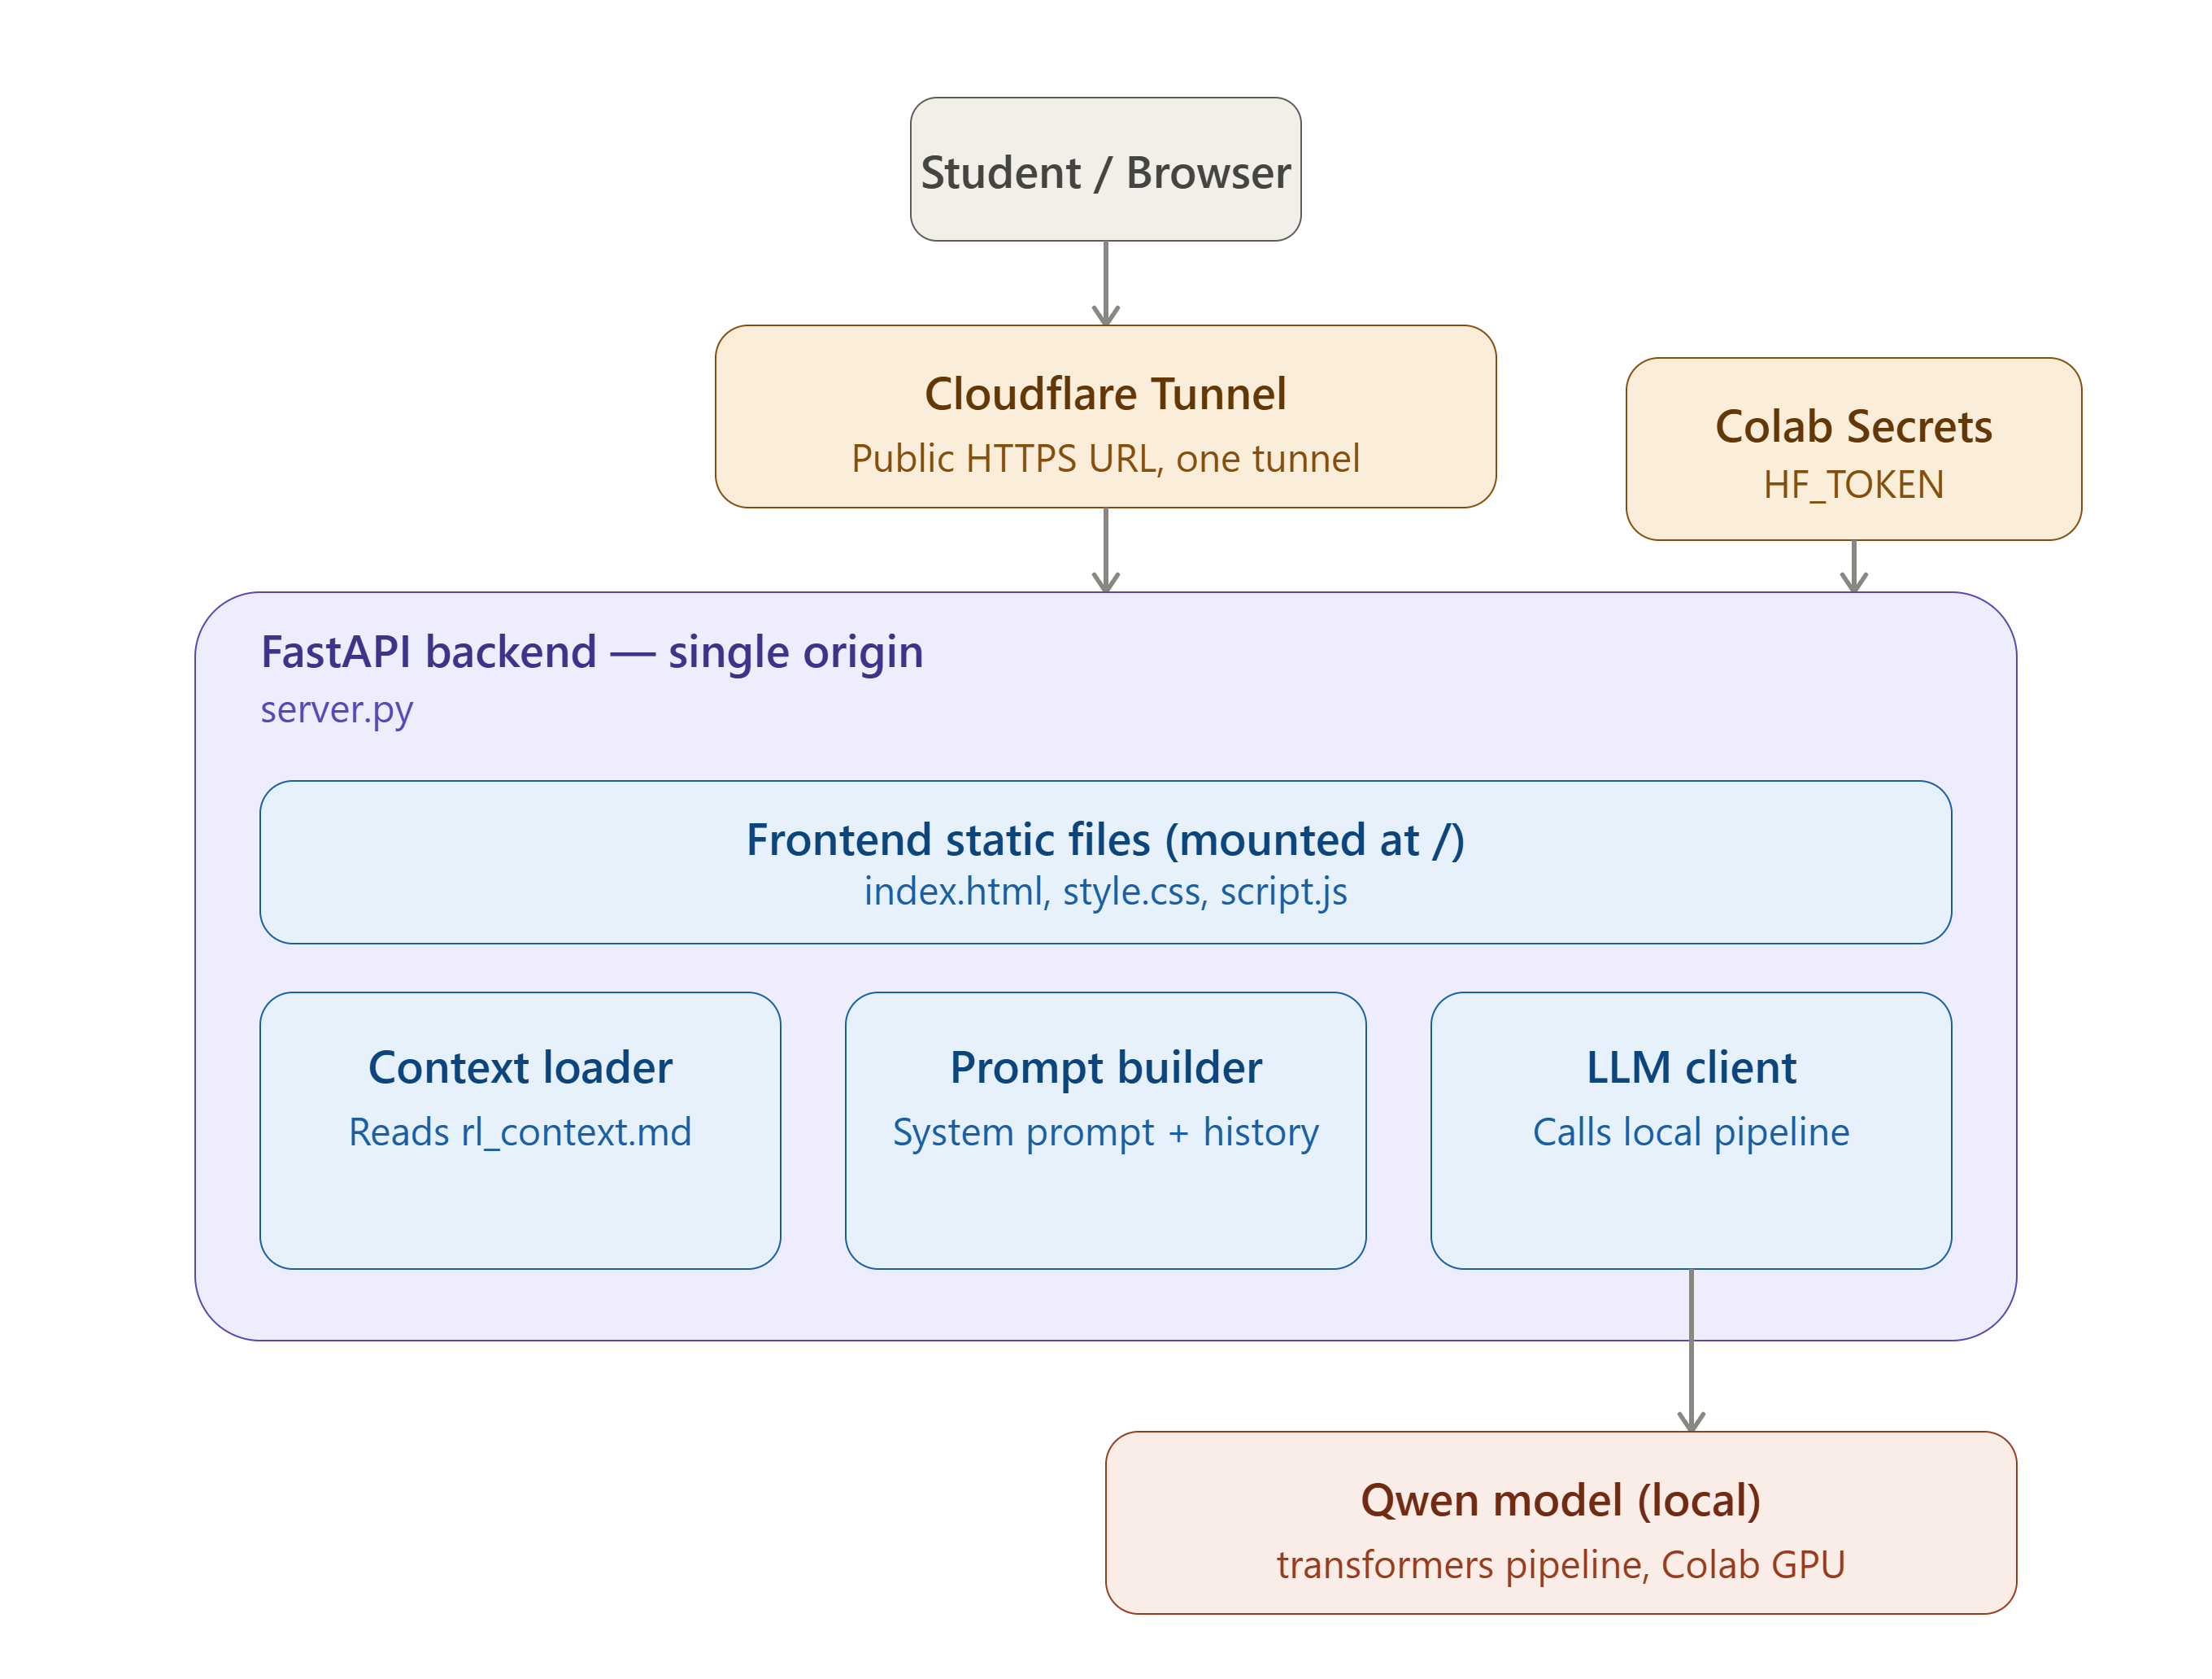